# Will AI Take Your Job? Analyzing Layoff Risk in the AI Era

**Research question:** Which factors most strongly predict AI-driven layoff risk across industries and roles, and which workers are most exposed?

This notebook analyzes a dataset of 20,000 employee records spanning 8 industries, capturing job characteristics (routine task %, creativity requirement, human interaction level) alongside AI-related factors (AI adoption level, tools used, usage hours, tasks automated) to understand what drives layoff risk classification (Low / Medium / High).

**Structure:**
1. Data Load & Overview
2. Data Cleaning & Validation
3. Exploratory Data Analysis
4. Key Findings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RISK_ORDER = ['Low', 'Medium', 'High']
RISK_COLORS = {'Low': '#55A868', 'Medium': '#DD8452', 'High': '#C44E52'}

sns.set_style("whitegrid")

## 1. Data Load & Overview

In [2]:
df = pd.read_excel("ai-impact-jobs-layoff-risk-dataset.xlsx")

In [3]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [5]:
df.shape

(20000, 16)

## 2. Data Cleaning & Validation

Before analyzing, we verify the dataset is reliable: no missing values, no duplicate records, and categorical fields are consistent.

In [6]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

### 3.1 Overall Layoff Risk Distribution

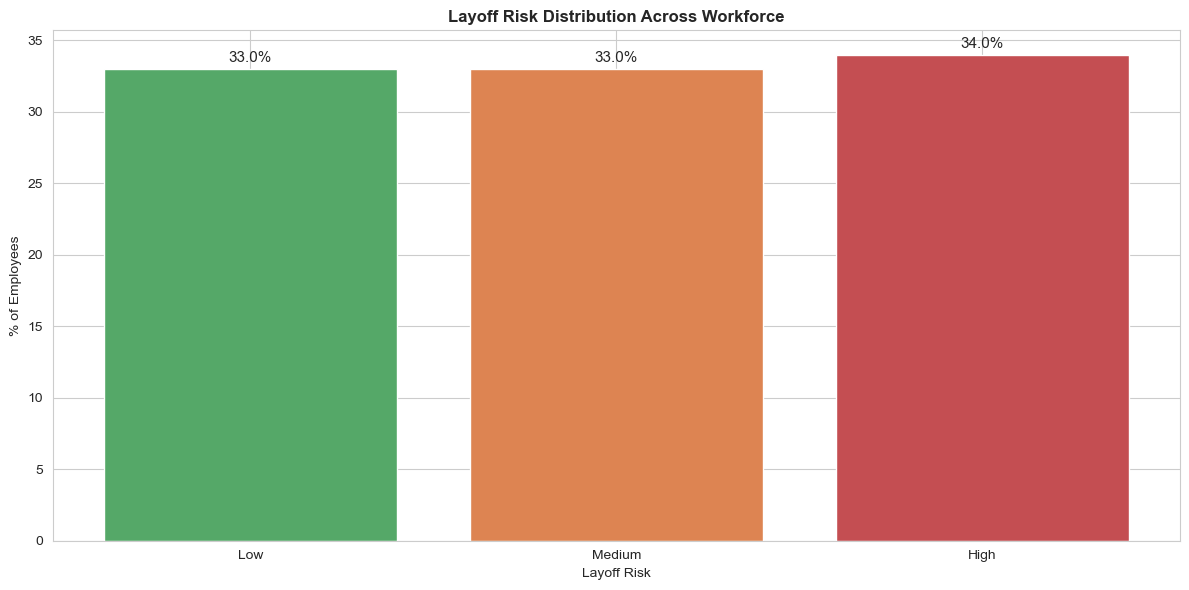

In [8]:
risk_counts = df['Layoff_Risk'].value_counts()
risk_percentage = ((risk_counts / len(df)) * 100).round(1).reindex(RISK_ORDER)

plt.figure(figsize=(12, 6))
bars = plt.bar(risk_percentage.index, risk_percentage.values,
                color=[RISK_COLORS[r] for r in risk_percentage.index])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%',
              ha='center', fontsize=11)

plt.title('Layoff Risk Distribution Across Workforce', fontweight='bold')
plt.xlabel('Layoff Risk')
plt.ylabel('% of Employees')
plt.tight_layout()
plt.show()

### 3.2 Layoff risk by Industries

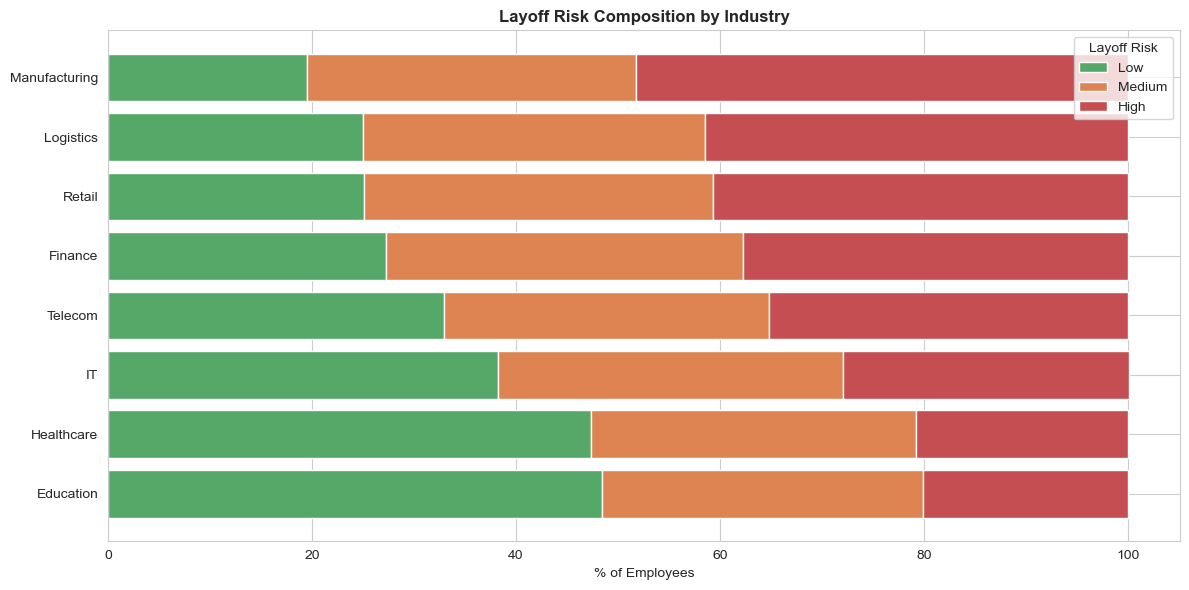

High-risk share by industry (sorted):
Industry
Manufacturing    48.2
Logistics        41.5
Retail           40.7
Finance          37.7
Telecom          35.2
IT               28.0
Healthcare       20.8
Education        20.1
Name: High, dtype: float64


In [9]:
industry_risk = (pd.crosstab(df['Industry'], df['Layoff_Risk'], normalize='index') * 100).round(1)
industry_risk = industry_risk[RISK_ORDER].sort_values('High', ascending=True)
industry_risk

plt.figure(figsize=(12, 6))

bottom = [0] * len(industry_risk)

for risk in RISK_ORDER:
    plt.barh(industry_risk.index, industry_risk[risk], left=bottom, 
              label=risk, color=RISK_COLORS[risk])
    bottom = bottom + industry_risk[risk].values

plt.title('Layoff Risk Composition by Industry', fontweight='bold')
plt.xlabel('% of Employees')
plt.legend(title='Layoff Risk')
plt.tight_layout()
plt.show()

print("High-risk share by industry (sorted):")
print(industry_risk['High'].sort_values(ascending=False).round(1))

### 3.3 Routine Task % and Automation % by Layoff Risk Level

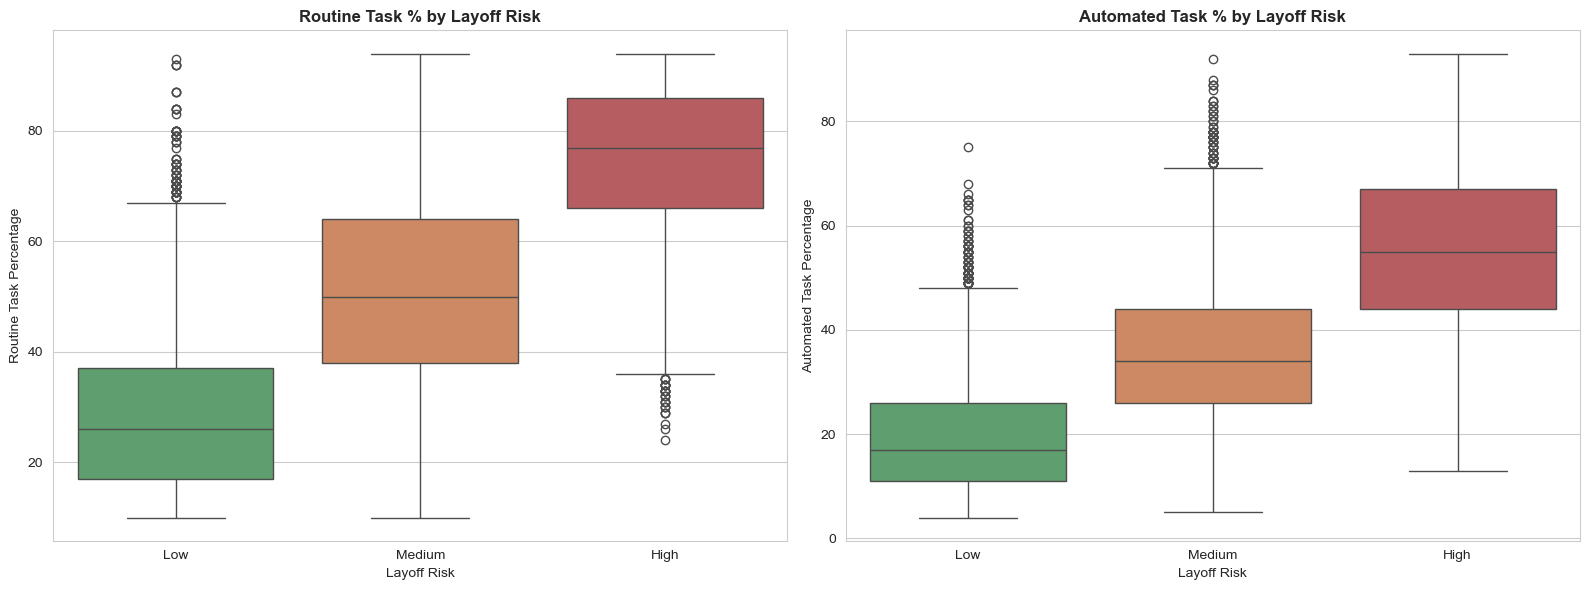

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Layoff_Risk', y='Routine_Task_Percentage', order=RISK_ORDER,
            hue='Layoff_Risk', palette=RISK_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Routine Task % by Layoff Risk', fontweight='bold')
axes[0].set_xlabel('Layoff Risk')
axes[0].set_ylabel('Routine Task Percentage')

sns.boxplot(data=df, x='Layoff_Risk', y='Tasks_Automated_Percentage', order=RISK_ORDER,
            hue='Layoff_Risk', palette=RISK_COLORS, legend=False, ax=axes[1])
axes[1].set_title('Automated Task % by Layoff Risk', fontweight='bold')
axes[1].set_xlabel('Layoff Risk')
axes[1].set_ylabel('Automated Task Percentage')

plt.tight_layout()
plt.show()

### 3.4 AI adoption level vs risk

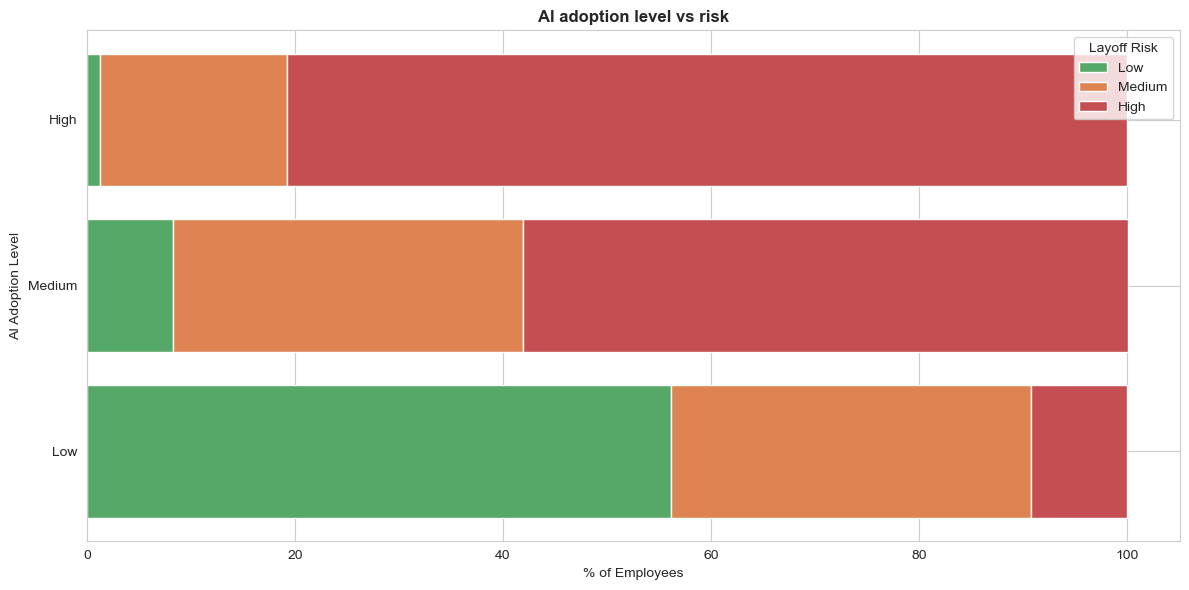

In [11]:
ai_adoption_risk = (pd.crosstab(df['AI_Adoption_Level'], df['Layoff_Risk'], normalize='index') * 100).round(1)
ai_adoption_risk = ai_adoption_risk[RISK_ORDER].sort_values('High', ascending=True)
ai_adoption_risk

plt.figure(figsize=(12, 6))

bottom = [0] * len(ai_adoption_risk)

for risk in RISK_ORDER:
    plt.barh(ai_adoption_risk.index, ai_adoption_risk[risk], left=bottom, 
              label=risk, color=RISK_COLORS[risk])
    bottom = bottom + ai_adoption_risk[risk].values

plt.title('AI adoption level vs risk', fontweight='bold')
plt.xlabel('% of Employees')
plt.ylabel('AI Adoption Level')
plt.legend(title='Layoff Risk')
plt.tight_layout()
plt.show()

### 3.5 Protective factors: Does Education_Level, Creativity_Requirement, or AI_Training_Hours seem to lower risk?

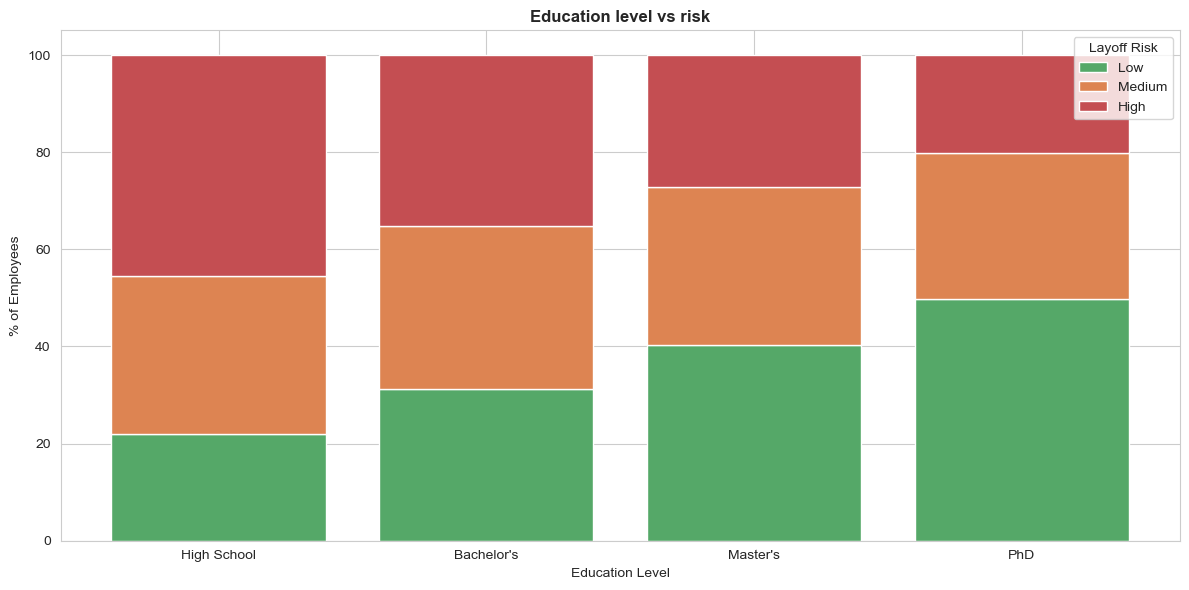

In [12]:
#3.5.1 Education_Level vs risk

edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
edu_risk = (pd.crosstab(df['Education_Level'], df['Layoff_Risk'], normalize='index') * 100).round(1)
edu_risk = edu_risk.reindex(edu_order)[RISK_ORDER]
edu_risk

plt.figure(figsize=(12, 6))

bottom = [0] * len(edu_risk)

for risk in RISK_ORDER:
    plt.bar(edu_risk.index, edu_risk[risk], bottom=bottom, 
              label=risk, color=RISK_COLORS[risk])
    bottom = bottom + edu_risk[risk].values

plt.title('Education level vs risk', fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('% of Employees')
plt.legend(title='Layoff Risk')
plt.tight_layout()
plt.show()

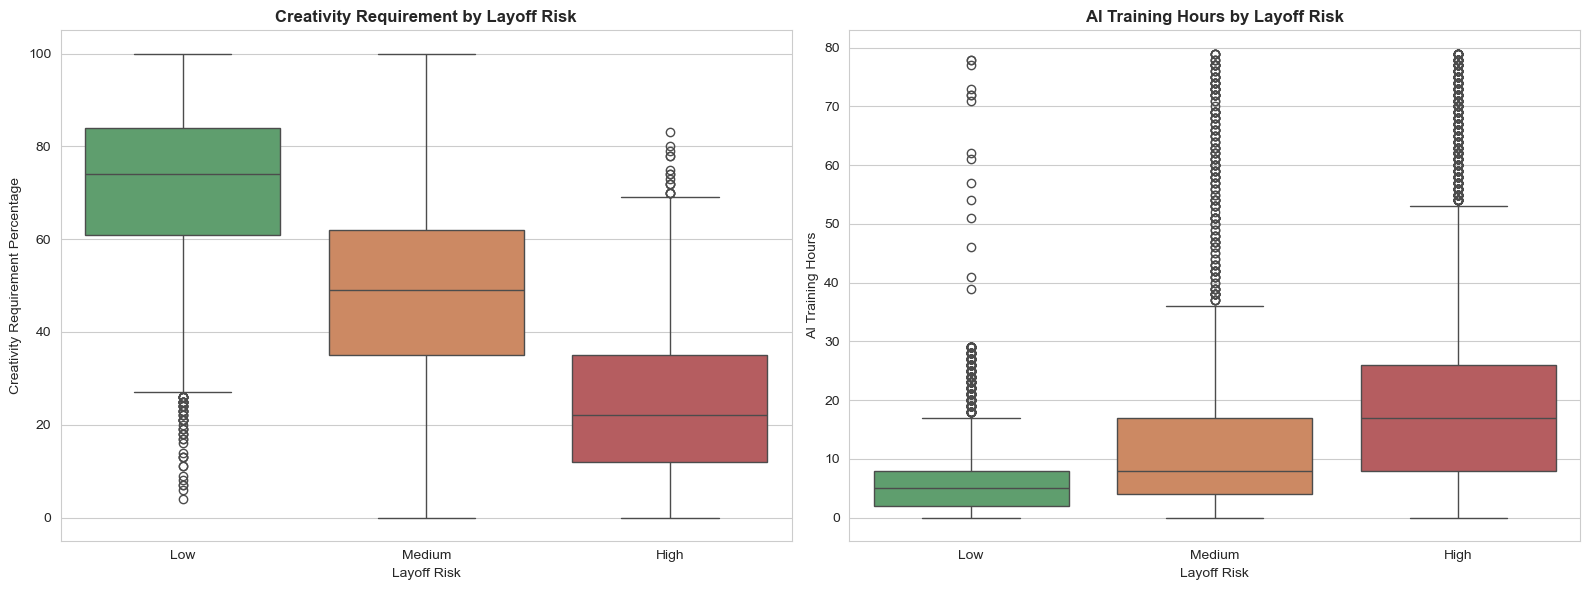

In [13]:
#3.5.2 Creativity Requirement % and AI Training Hours % by Layoff Risk Level

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Layoff_Risk', y='Creativity_Requirement', order=RISK_ORDER,
            hue='Layoff_Risk', palette=RISK_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Creativity Requirement by Layoff Risk', fontweight='bold')
axes[0].set_xlabel('Layoff Risk')
axes[0].set_ylabel('Creativity Requirement Percentage')

sns.boxplot(data=df, x='Layoff_Risk', y='AI_Training_Hours', order=RISK_ORDER,
            hue='Layoff_Risk', palette=RISK_COLORS, legend=False, ax=axes[1])
axes[1].set_title('AI Training Hours by Layoff Risk', fontweight='bold')
axes[1].set_xlabel('Layoff Risk')
axes[1].set_ylabel('AI Training Hours')

plt.tight_layout()
plt.show()

### 3.6 Does seniority (Entry/Mid/Senior) protect against risk?

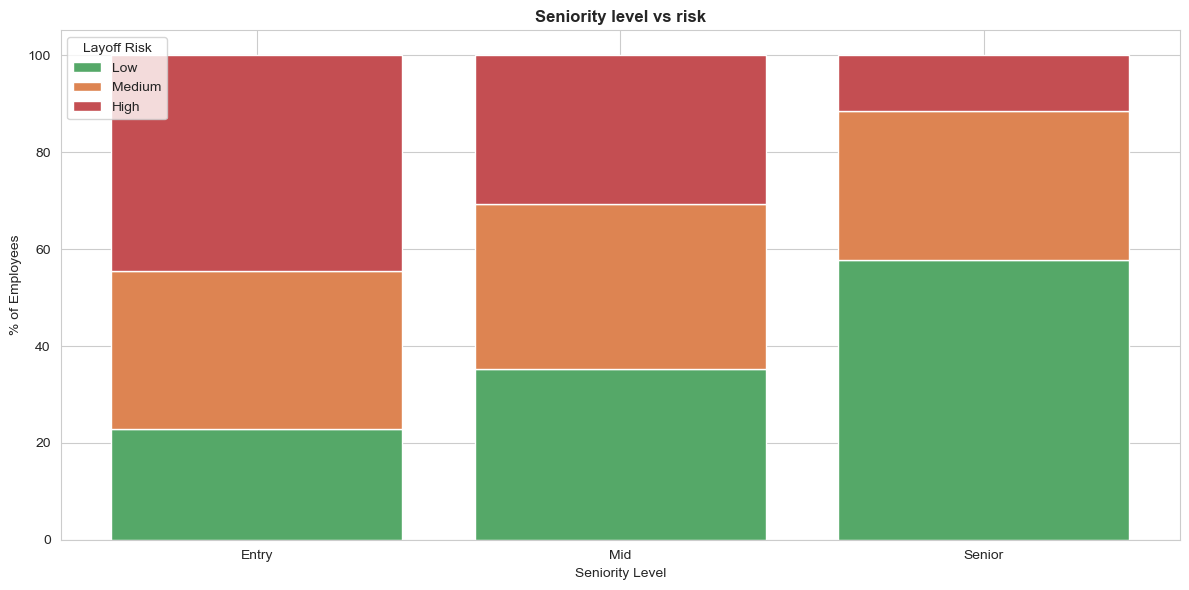

In [14]:
job_level_order = ['Entry', 'Mid', 'Senior']
job_level_risk = (pd.crosstab(df['Job_Level'], df['Layoff_Risk'], normalize='index') * 100).round(1)
job_level_risk = job_level_risk.reindex(job_level_order)[RISK_ORDER]
job_level_risk

plt.figure(figsize=(12, 6))

bottom = [0] * len(job_level_risk)

for risk in RISK_ORDER:
    plt.bar(job_level_risk.index, job_level_risk[risk], bottom=bottom, 
              label=risk, color=RISK_COLORS[risk])
    bottom = bottom + job_level_risk[risk].values

plt.title('Seniority level vs risk', fontweight='bold')
plt.xlabel('Seniority Level')
plt.ylabel('% of Employees')
plt.legend(title='Layoff Risk')
plt.tight_layout()
plt.show()

### 3.7 Which Job Roles Face the Highest AI-Driven Layoff Risk?

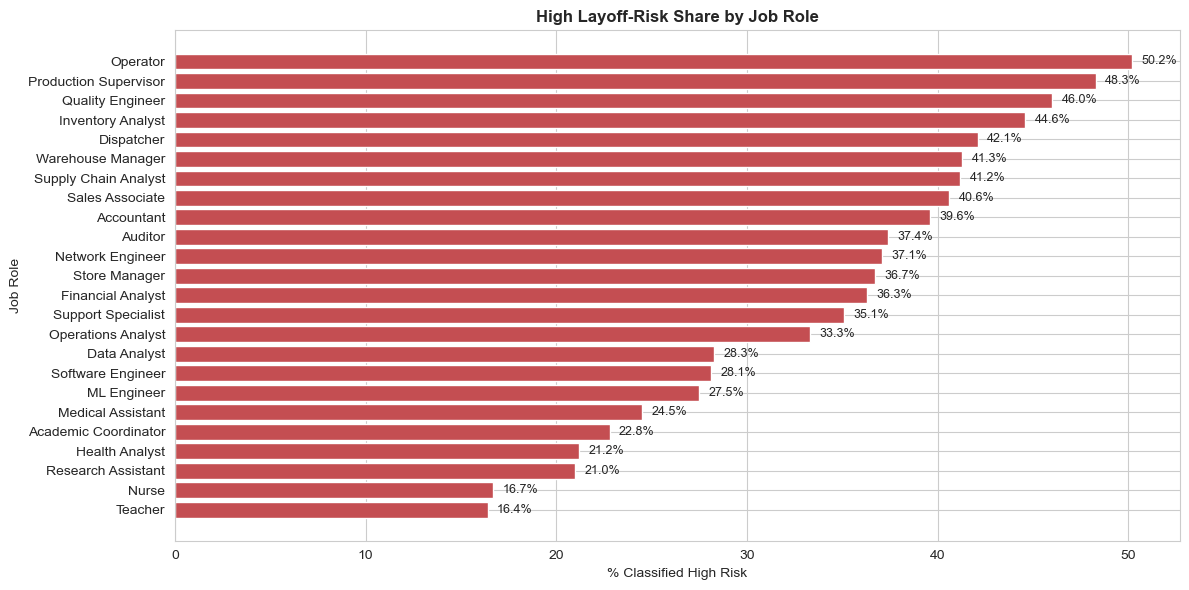

In [15]:
job_role_risk = (pd.crosstab(df['Job_Role'], df['Layoff_Risk'], normalize='index') * 100).round(1)
role_high = job_role_risk['High'].sort_values(ascending=True)

plt.figure(figsize=(12, 6))

bars = plt.barh(role_high.index, role_high.values, color=RISK_COLORS['High'])

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}%',
              va='center', fontsize=9)

plt.title('High Layoff-Risk Share by Job Role', fontweight='bold')
plt.xlabel('% Classified High Risk')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

### 3.8 Correlation Matrix: Numeric Features

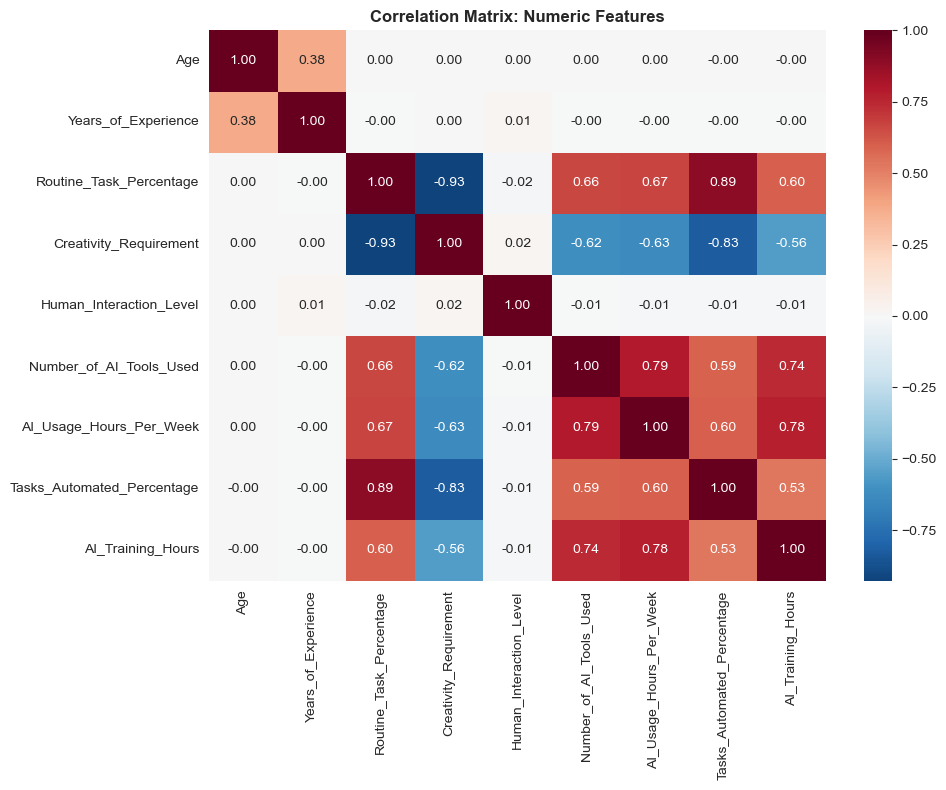

In [16]:
numeric_cols = ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement',
                 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
                 'Tasks_Automated_Percentage', 'AI_Training_Hours']

corr = df[numeric_cols].corr()
corr

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Key Findings

1. **Layoff risk is roughly evenly split across the workforce** — 34.0% High, 33.0% Medium, 33.0% Low — meaning a third of all employees analyzed already fall into the highest AI-driven risk category.

2. **Manufacturing carries the highest layoff risk at 48.2%**, followed by Logistics (41.5%) and Retail (40.7%) — industries dominated by routine, process-heavy roles. Education (20.1%) and Healthcare (20.8%) are the safest, reflecting roles built around human judgment and interaction.

3. **Routine and automatable work is the clearest driver of risk.** Median Routine_Task_Percentage rises from approx. 25% (Low risk) to approx. 50% (Medium) to approx. 77% (High) — a clean staircase. The same pattern holds for Tasks_Automated_Percentage (~17% → ~34% → ~55%), confirming that *what a job involves* matters more than which industry it's in.

4. **Company AI adoption level dramatically amplifies risk.** Only ~9% of employees at Low-AI-adoption companies are High risk, versus ~81% at High-AI-adoption companies — showing that organizational AI strategy compounds task-level exposure, not just individual role content.

5. **Education and seniority both act as protective factors, of similar strength.** High-risk share drops from 45.6% (High School) to 20.1% (PhD), and from 44.5% (Entry-level) to 11.5% (Senior) — roughly a 2-4x reduction at each end. Interestingly, **AI training hours do *not* show the same protective pattern** — High-risk employees actually receive the *most* training (median ~17 hrs) versus Low-risk employees (median ~5 hrs), suggesting training is being deployed reactively to already-automating roles, rather than proactively preventing risk.

6. **Job role rankings sharpen the industry-level picture.** Operator (50.2%), Production Supervisor (48.3%), and Quality Engineer (46.0%) face the highest risk; Teacher (16.4%), Nurse (16.7%), and Research Assistant (21.0%) face the lowest. Notably, technical/analytical roles like Data Analyst (28.3%), Software Engineer (28.1%), and ML Engineer (27.5%) sit in the middle — meaningfully lower than production roles, but not risk-free.

7. **Routine task content and creativity are near-mirror opposites** (correlation −0.93), while Routine_Task_Percentage and Tasks_Automated_Percentage move together strongly (+0.89). Age, Years_of_Experience, and Human_Interaction_Level show almost no relationship with any AI-exposure variable — demographic factors appear largely unrelated to AI-driven risk, unlike job content itself.

### Next steps
- Segment by Job_Level *within* high-automation roles to see if seniority protects even in the riskiest job categories.
- Build a predictive model to rank all features by importance simultaneously, rather than one at a time.
- Explore whether AI_Training_Hours changes risk trajectory *over time* (this dataset is a single snapshot, so causality can't be confirmed here).